In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

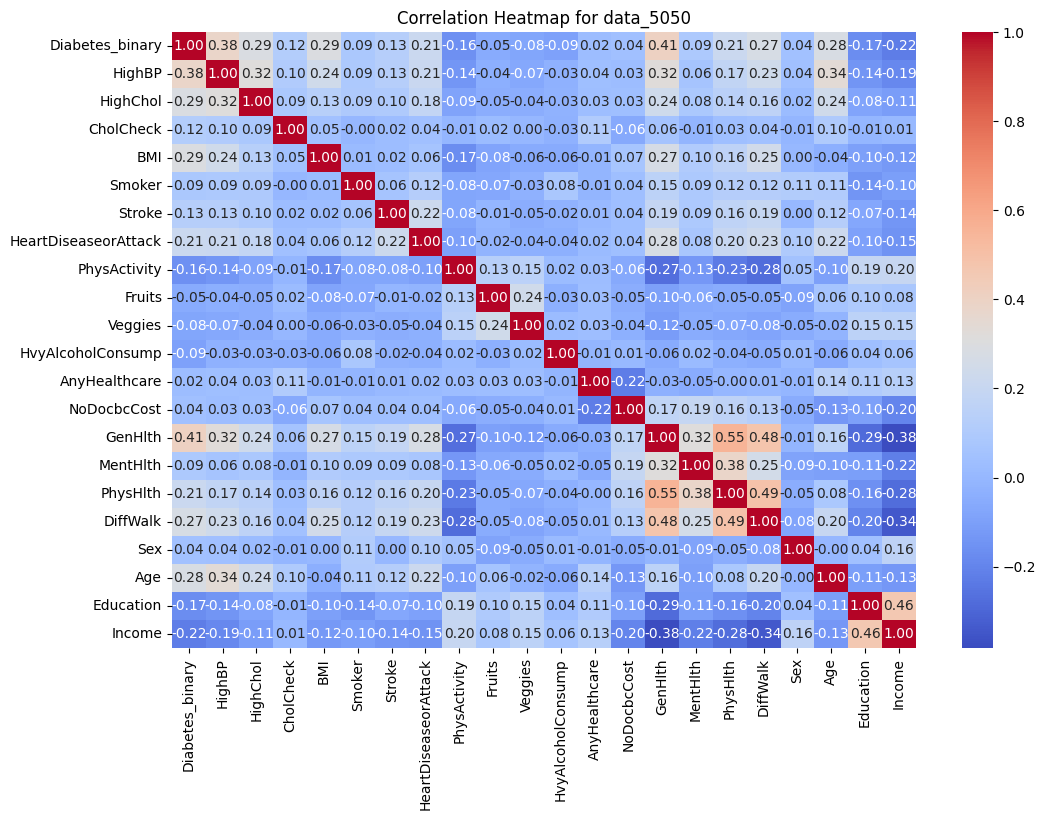

In [4]:
df_012 = pd.read_csv('/Users/rita/Downloads/archive/diabetes_012_health_indicators_BRFSS2015.csv')
df_binary = pd.read_csv('/Users/rita/Downloads/archive/diabetes_binary_health_indicators_BRFSS2015.csv')
df_5050 = pd.read_csv('/Users/rita/Downloads/archive/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')

df_5050.head(), df_5050.info(), df_5050.describe()
numeric_df_5050 = df_5050.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df_5050.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for data_5050')
plt.show()

In [19]:
#拆分训练集 & 测试集
X = df_5050.drop(columns=["Diabetes_binary"])  # 特征
y = df_5050["Diabetes_binary"]  # 目标变量
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [ ]:
#Logisitic regression
lr = LogisticRegression(max_iter=500, solver="lbfgs")
lr.fit(X_train, y_train)
lr_y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_y_pred))
print(classification_report(y_test, lr_y_pred))

Accuracy: 0.7477898012589292
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74      7069
         1.0       0.74      0.77      0.75      7070

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [20]:
#Random Forest
rf = RandomForestClassifier(n_estimators=125, max_depth=10,random_state=42)
rf.fit(X_train, y_train)
rf_y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_y_pred))
print(classification_report(y_test, rf_y_pred))

Accuracy: 0.745880189546644
              precision    recall  f1-score   support

         0.0       0.77      0.70      0.73      7070
         1.0       0.73      0.79      0.76      7069

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



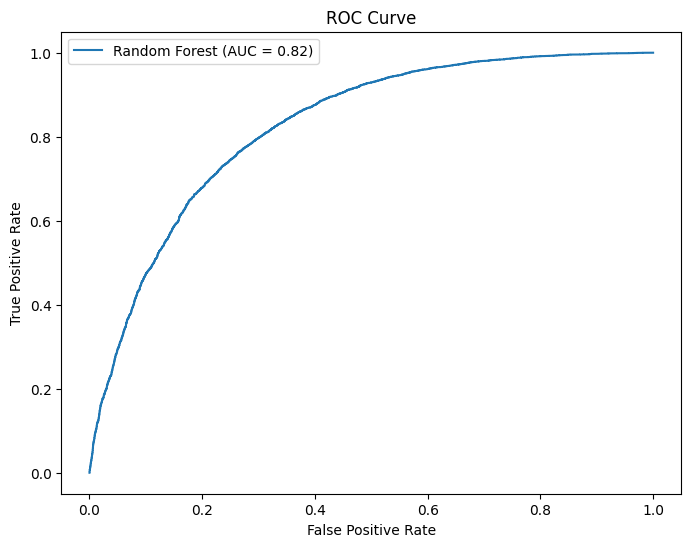

In [8]:
y_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label="Random Forest (AUC = {:.2f})".format(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

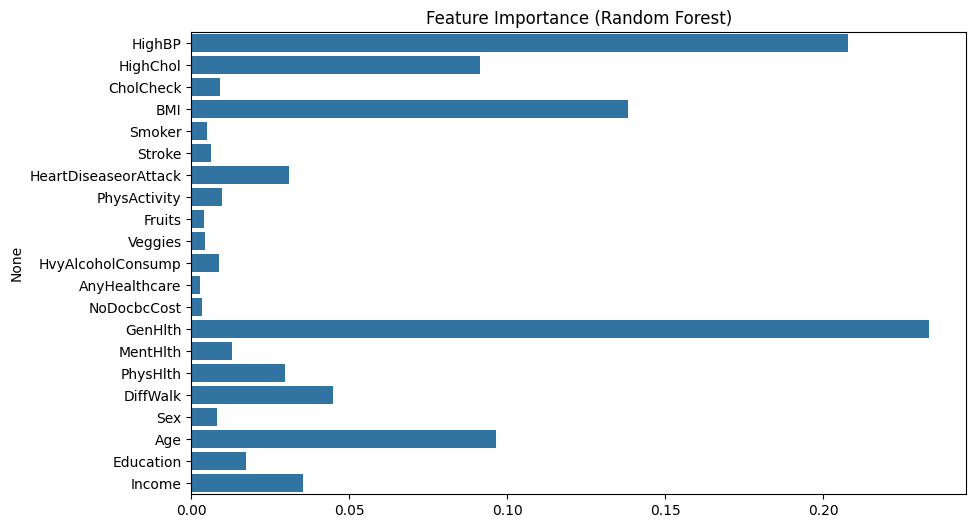

In [9]:
importances = rf.feature_importances_
feature_names = X.columns

# 可视化重要特征
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [10]:
#XG Boost
xgb = XGBClassifier(eval_metric="logloss")
xgb.fit(X_train, y_train)
xgb_y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_y_pred))
print(classification_report(y_test, xgb_y_pred))

Accuracy: 0.7478605276186435
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74      7069
         1.0       0.73      0.79      0.76      7070

    accuracy                           0.75     14139
   macro avg       0.75      0.75      0.75     14139
weighted avg       0.75      0.75      0.75     14139



In [ ]:
def binary_search(n_estimators,k):
    for i in range(k):
        

In [17]:
param_grid = {
    "n_estimators": [100,125,150],
    "max_depth": [None,10,20]
    ##"min_samples_split": [2, 5, 10],  # 控制分裂规则
    ##"min_samples_leaf": [1, 2, 4],  # 叶子节点最小样本数
    ##"max_features": ["sqrt", "log2", None],  # 选择特征数
}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [34]:
#ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [22]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 2s 785us/step - accuracy: 0.7240 - loss: 0.5459 - val_accuracy: 0.7435 - val_loss: 0.5126
Epoch 2/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - accuracy: 0.7491 - loss: 0.5122 - val_accuracy: 0.7461 - val_loss: 0.5090
Epoch 3/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step - accuracy: 0.7520 - loss: 0.5069 - val_accuracy: 0.7485 - val_loss: 0.5084
Epoch 4/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step - accuracy: 0.7526 - loss: 0.5042 - val_accuracy: 0.7474 - val_loss: 0.5070
Epoch 5/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 1s 793us/step - accuracy: 0.7512 - loss: 0.5058 - val_accuracy: 0.7484 - val_loss: 0.5071
Epoch 6/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 1s 687us/step - accuracy: 0.7599 - loss: 0.4983 - val_accuracy: 0.7486 - val_loss: 0.5080
Epoch 7/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 1s 691us/step - accuracy: 0.7539 - loss: 0.5051 - val_accuracy: 0.7476 - val_loss: 0.5077
Epoch 8/50
1768/1768 ━━━━━━━━━━━━━━━━━━━━ 1s 712us/step - accuracy: 0.7550 -

In [23]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

442/442 ━━━━━━━━━━━━━━━━━━━━ 0s 485us/step - accuracy: 0.7437 - loss: 0.5114
Test Accuracy: 0.7453


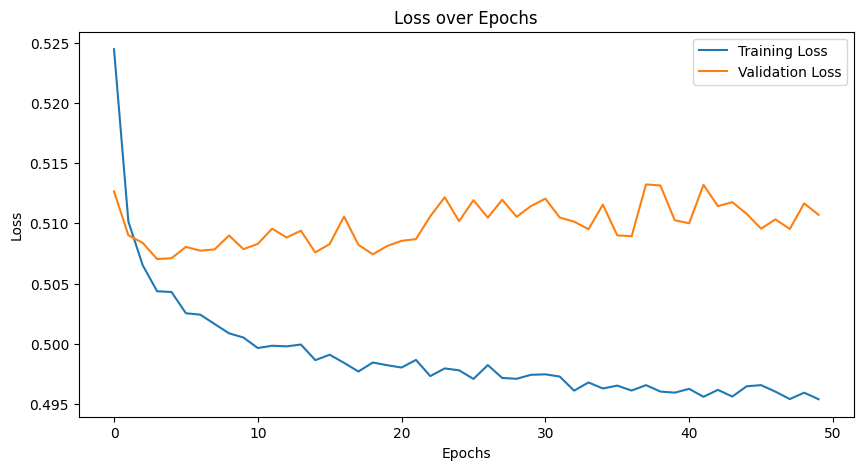

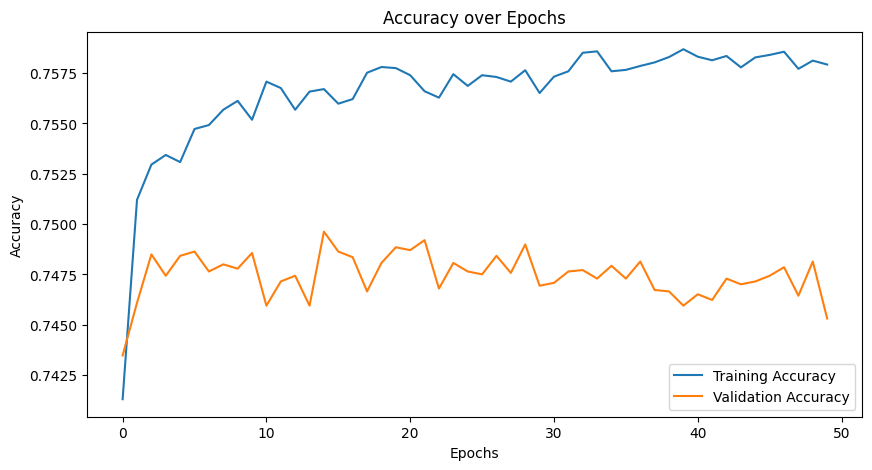

In [24]:
# 绘制训练和验证损失
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss over Epochs")
plt.show()

# 绘制训练和验证准确率
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy over Epochs")
plt.show()


In [35]:
def predict_diabetes(data):
    data_scaled = scaler.transform([data])
    prob = model.predict(data_scaled)[0,0]
    return "High risk" if prob > 0.5 else "Low risk"
sample_input = [25, 45, 1, 0, 120, 80, 30, 1, 0, 1, 0, 0, 1, 20, 35, 0, 1, 2, 3, 1, 0]
print("Diabetes Risk:", predict_diabetes(sample_input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Diabetes Risk: High risk


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
